In [1]:
pip install uvicorn fastapi pandas joblib scikit-learn numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


✅ Accuracy on Validation Set: 99.32%
✅ Model, Scaler, and Encoder saved to /models
✅ Visuals saved to /visuals


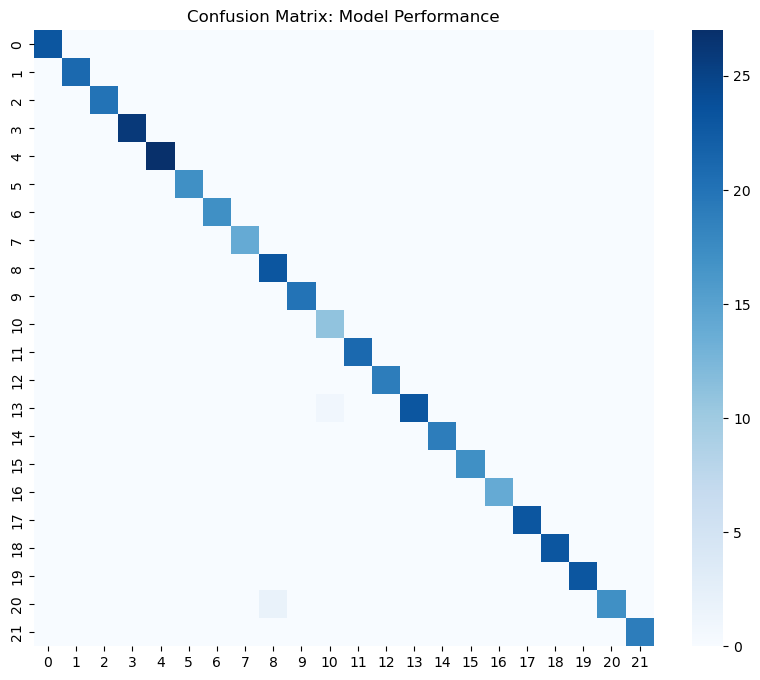

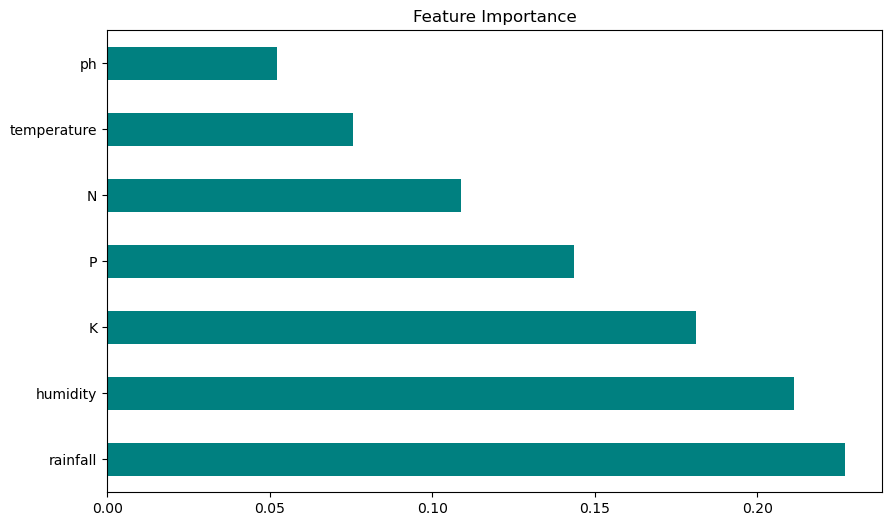

In [3]:
import pandas as pd
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

def run_training_pipeline():
    # 1. Setup Directories
    os.makedirs('models', exist_ok=True)
    os.makedirs('visuals', exist_ok=True)
    
    # 2. Load and Clean Data
    file_path = r"D:\ai farmer\Crop_recommendation.csv"
    df = pd.read_csv(file_path)
    # Automatic removal of any rows with missing values
    df.dropna(inplace=True) 

    X = df.drop('label', axis=1)
    y = df['label']

    # 3. Scaling & Encoding
    scaler = StandardScaler()
    le = LabelEncoder()

    X_scaled = scaler.fit_transform(X)
    y_encoded = le.fit_transform(y)

    # 4. Training
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 5. Visualization
    y_pred = model.predict(X_test)
    
    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=False, cmap='Blues')
    plt.title('Confusion Matrix: Model Performance')
    plt.savefig('visuals/confusion_matrix.png')
    
    # Feature Importance
    plt.figure(figsize=(10, 6))
    pd.Series(model.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh', color='teal')
    plt.title('Feature Importance')
    plt.savefig('visuals/feature_importance.png')
    
    # 6. Output Metrics & Save Artifacts
    print(f"✅ Accuracy on Validation Set: {accuracy_score(y_test, y_pred):.2%}")
    print("✅ Model, Scaler, and Encoder saved to /models")
    print("✅ Visuals saved to /visuals")

    joblib.dump(model, 'models/crop_model.pkl')
    joblib.dump(scaler, 'models/scaler.pkl')
    joblib.dump(le, 'models/label_encoder.pkl')

if __name__ == "__main__":
    run_training_pipeline()

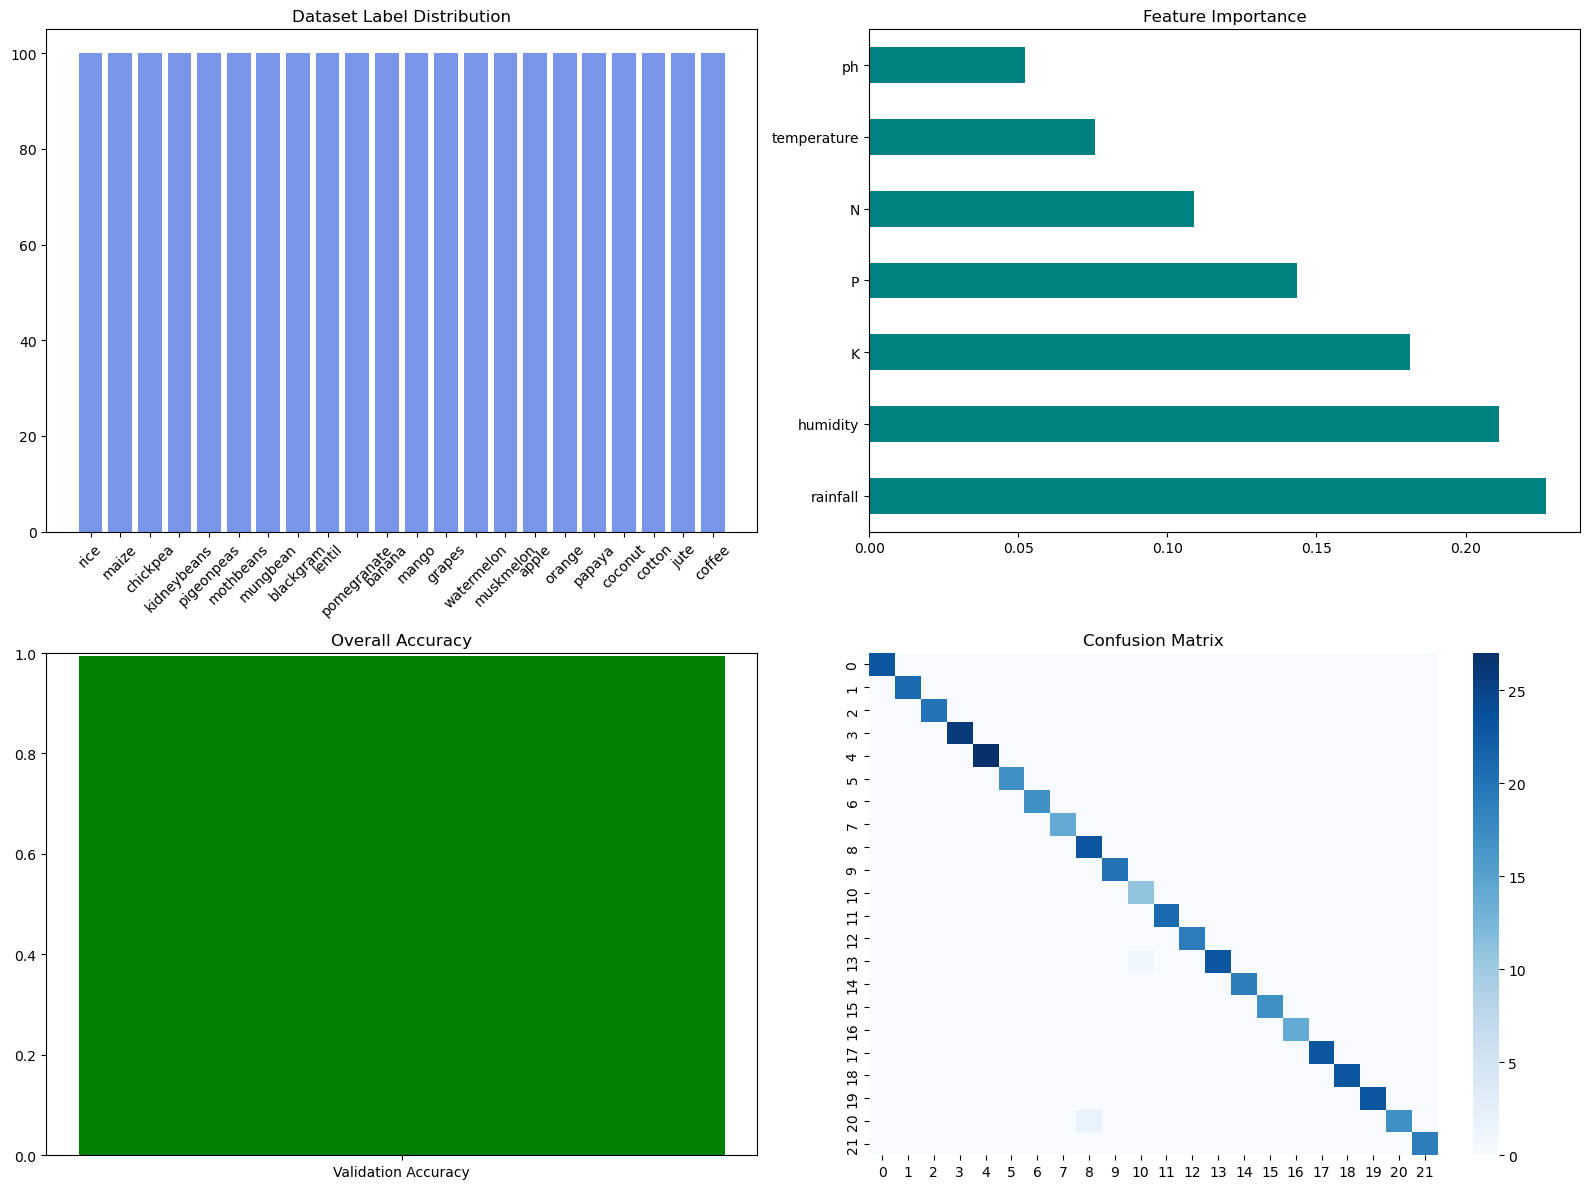

✅ Pipeline Complete. Accuracy: 99.32%


In [20]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Setup and Load Data
def run_full_pipeline():
    os.makedirs('models', exist_ok=True)
    os.makedirs('visuals', exist_ok=True)
    
    file_path = r"D:\ai farmer\Crop_recommendation.csv"
    df = pd.read_csv(file_path)
    df.dropna(inplace=True) 

    X = df.drop('label', axis=1)
    y = df['label']
    class_names = df['label'].unique()

    # 2. Scale & Encode
    scaler = StandardScaler()
    le = LabelEncoder()
    X_scaled = scaler.fit_transform(X)
    y_encoded = le.fit_transform(y)

    # 3. Train
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # 4. Save Artifacts
    joblib.dump(model, 'models/crop_model.pkl')
    joblib.dump(scaler, 'models/scaler.pkl')
    joblib.dump(le, 'models/label_encoder.pkl')

    # 5. Generate Dashboard
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # A. Label Distribution
    class_counts = df['label'].value_counts()
    axes[0, 0].bar(class_counts.index, class_counts.values, color='royalblue', alpha=0.7)
    axes[0, 0].set_title('Dataset Label Distribution')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # B. Feature Importance
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.nlargest(10).plot(kind='barh', ax=axes[0, 1], color='teal')
    axes[0, 1].set_title('Feature Importance')
    
    # C. Accuracy (Bar representation of classes)
    axes[1, 0].bar(['Validation Accuracy'], [accuracy_score(y_test, y_pred)], color='green')
    axes[1, 0].set_title('Overall Accuracy')
    axes[1, 0].set_ylim(0, 1)
    
    # D. Confusion Matrix
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[1, 1])
    axes[1, 1].set_title('Confusion Matrix')

    plt.tight_layout()
    plt.savefig('visuals/full_project_dashboard.png')
    plt.show()

    print(f"✅ Pipeline Complete. Accuracy: {accuracy_score(y_test, y_pred):.2%}")

# Run the complete process
run_full_pipeline()

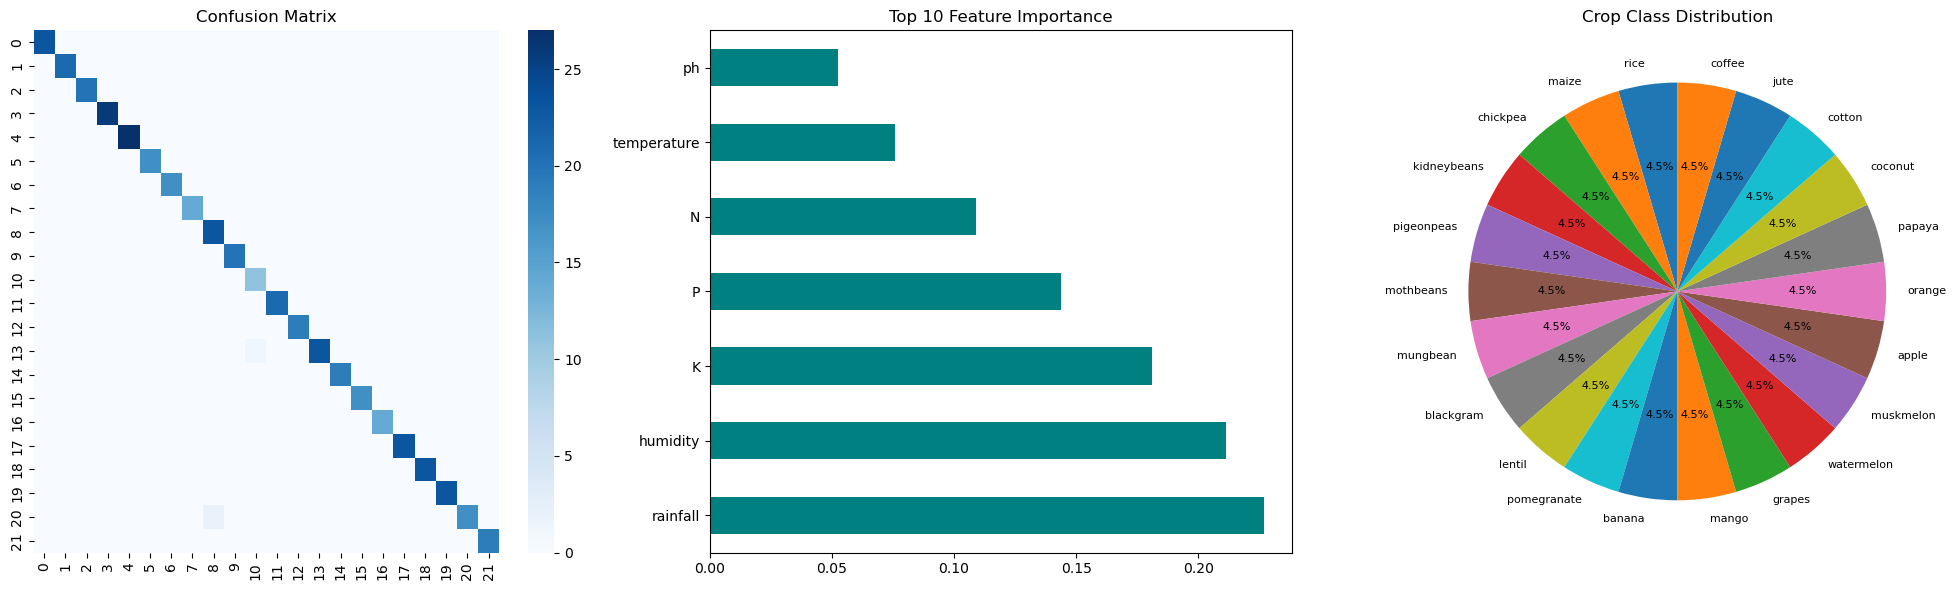

✅ Accuracy: 99.32%
✅ Dashboard saved to /visuals/evaluation_dashboard.png


In [14]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

def run_training_pipeline():
    # 1. Setup Folders
    os.makedirs('models', exist_ok=True)
    os.makedirs('visuals', exist_ok=True)
    
    # 2. Load & Clean Data
    file_path = r"D:\ai farmer\Crop_recommendation.csv"
    df = pd.read_csv(file_path)
    df.dropna(inplace=True) 

    X = df.drop('label', axis=1)
    y = df['label']

    # 3. Scale & Encode
    scaler = StandardScaler()
    le = LabelEncoder()
    X_scaled = scaler.fit_transform(X)
    y_encoded = le.fit_transform(y)

    # 4. Train Model
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # --- VISUALIZATION DASHBOARD ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # A. Confusion Matrix
    y_pred = model.predict(X_test)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=False, cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')

    # B. Feature Importance (Bar Graph)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.nlargest(10).plot(kind='barh', ax=axes[1], color='teal')
    axes[1].set_title('Top 10 Feature Importance')

    # C. Class Distribution (Pie Chart)
    class_counts = df['label'].value_counts()
    axes[2].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
    axes[2].set_title('Crop Class Distribution')

    plt.tight_layout()
    plt.savefig('visuals/evaluation_dashboard.png')
    plt.show()

    # 5. Export Artifacts
    joblib.dump(model, 'models/crop_model.pkl')
    joblib.dump(scaler, 'models/scaler.pkl')
    joblib.dump(le, 'models/label_encoder.pkl')
    
    print(f"✅ Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print("✅ Dashboard saved to /visuals/evaluation_dashboard.png")

run_training_pipeline()

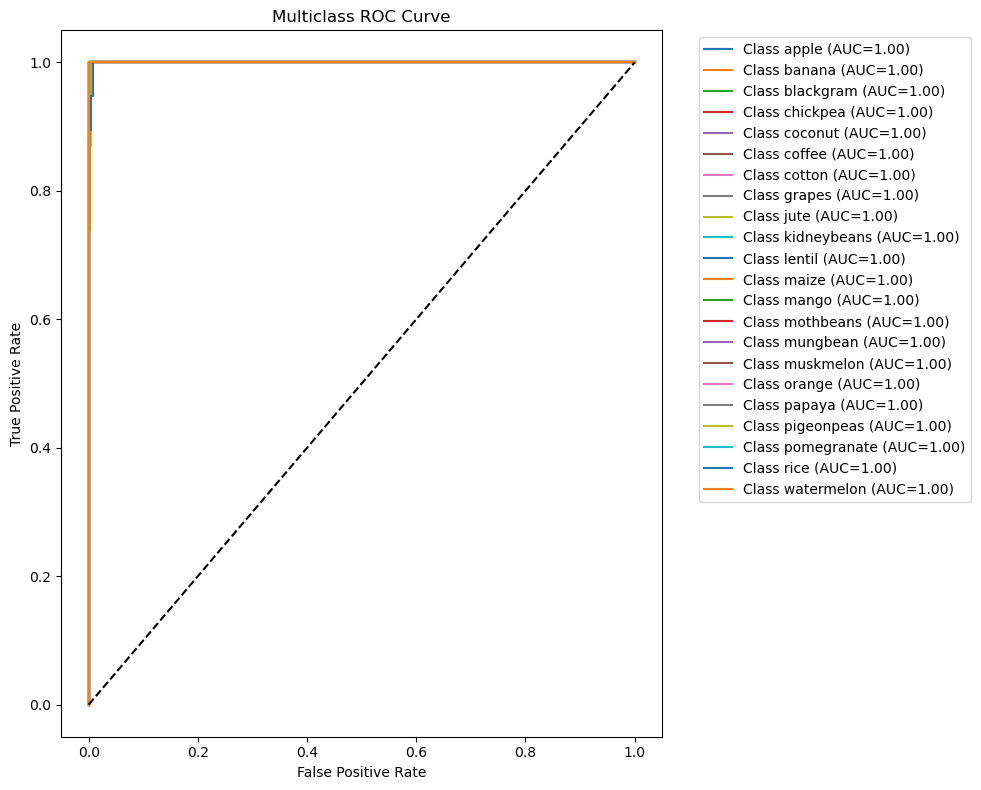

In [17]:
# 1. Ensure the model is trained
# If you already have the X_train/y_train from before, just run:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. Now perform the ROC analysis
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Binarize the output for multi-class ROC
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_score = model.predict_proba(X_test)

plt.figure(figsize=(10, 8))
# Plotting ROC for each class
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC={auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()